#### HW5 
Plot as a function of x the pressure distribution normalized by the stagnation pressure for the attached nozzle profile. The profile is given in terms of a two column matrix where the first column is the x location and the second column is the radius of an axisymmetric circular nozzle through which the flow goes through. Assume air and CPG. 

1. Case 1: fully subsonic, you may choose a back pressure
2. Case 2: fully subsonic, with the throat at sonic, what is the back pressure?
3. Case 3: Normal shock at x = 0.75 in the nozzle, what is the back pressure?
4. Case 4: Normal shock at the exit of the nozzle, what is the back pressure?
5. Case 5: Ideally expanded, what is the back pressure?
6. What pressure range corresponds to oblique shockwaves at the exit of the nozzle?
7. What pressure range corresponds to expansion waves at the exit of the nozzle

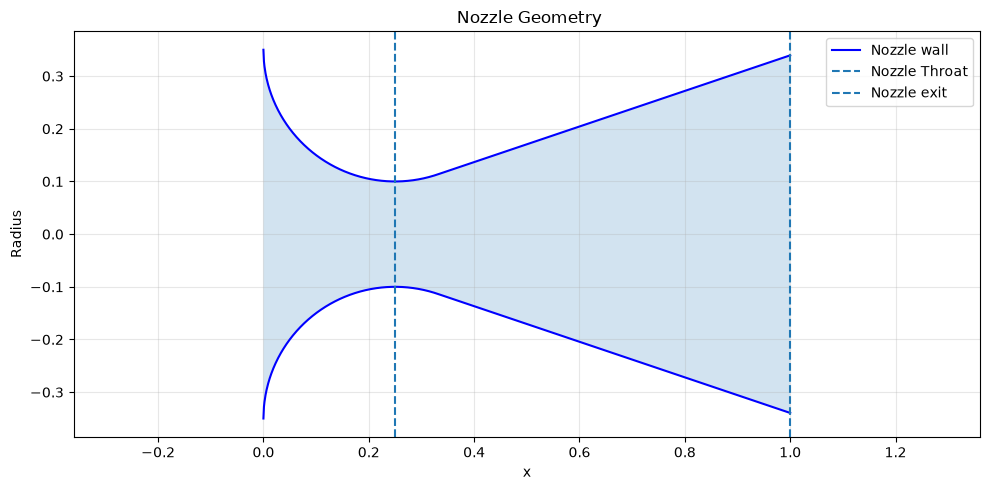

In [16]:
import numpy as np
import matplotlib.pyplot as plt 
from scipy.optimize import brentq


gamma = 1.4
Nozzle = np.loadtxt("Pnozzle.txt", delimiter=",")
Nozzle_Geom = []

x = Nozzle[:, 0]     
r = Nozzle[:, 1]
A = r * r * np.pi

Nozzle_Geom.append([x, r, A])
A_star = A[np.argmin(A)]
A_e = A[-1]

plt.figure(figsize=(10, 5))
plt.plot(x, r, color = 'b', label='Nozzle wall')
plt.plot(x, -r, color = 'b' )
plt.fill_between(x, -r, r, alpha = 0.2)
plt.axvline( x=x[A == A_star], linestyle='--', label='Nozzle Throat')
plt.axvline( x=x[A == A_e], linestyle='--', label='Nozzle exit')
plt.xlabel("x")
plt.ylabel("Radius")
plt.title(" Nozzle Geometry")
plt.axis("equal")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()



<img src="https://github.com/DanielKim0208/ME-433RocketScience/blob/main/HW5/area-Mach%20number%20relation.png?raw=true" width="50%">
<img src="https://github.com/DanielKim0208/ME-433RocketScience/blob/main/HW5/Isentropic%20Flow%20NASA.gif?raw=true" width="50%">


In [ ]:
#MachFromArea function takes in the Area ratio, gamma, type
def MachFromArea (A_ratio, gamma, type):
    
    #This is the 'sub-function' that returns Area ratio subtracted by the given Area ratio to be optimized by Brentq, where solution will be zero.  
    def f (m_i):
        M = m_i ** 2 
        Relation = (1/M) * ((2/(gamma +1)) * (1 + ((gamma - 1)/2 * M))) ** ((gamma+1)/(gamma-1))
        return Relation - A_ratio ** 2
    
    if type == "subsonic":
        return brentq(f, 0.001, 1)
    else:
        return brentq(f, 1, 10)


# I verified Using the NASA Isentropic Flow calculator : https://www.grc.nasa.gov/www/k-12/airplane/isentrop.html
print(MachFromArea(1.1, 1.4, "subsonic"))   
print(MachFromArea(2.0, 1.4, "supersonic"))  


#The function finds Mach number from the given pressure ratio. It sweeps only from 0.528 to 1, to not account for the normal shock. 
def MachFromPressure(P_ratio, gamma): 
    def f(m_i): 
        M = m_i ** 2 
        Relation = (1 + ((gamma-1)/2)*M) **((-gamma)/(gamma-1))
        return Relation - P_ratio
    return brentq(f,0.528, 1)

#This function calculates the normalized pressure ratio as the function of area ratio
def PressureRatio(A_ratio, gamma, type): 
    m = MachFromArea(A_ratio, gamma, type)
    M = m * m
    P_ratio = (1 + ((gamma -1)/2) * M) ** (-gamma / (gamma - 1))
    return P_ratio

def AreaRatio(m_i, gamma): 
    M = m_i ** 2 
    A_ratio = np.sqrt(1/M * ((2/(gamma+1))*(1 + ((gamma-1)/2) * M)) ** ((gamma+1)/(gamma-1)))
    return A_ratio


0.6923991394638542
2.1971981216521863


#### PART A 
Fully subsonic case, with arbitary back pressure. 
I chose 95% of critical back pressure

1. Calculate the imaginary area Astar where M=1 as a ratio to A_e 
2. Calculate the Mach number of A_given / Imaginary A_star
3. Calculate the normalized pressure ratio based on the area ratio found in step 2.
4. Plot the results

In [53]:
#Exit Area to Throat Ratio, Ae/Ao 
gamma = 1.4
Pb = 0.7
M_e = MachFromPressure(Pb, gamma)

#As the flow is fully subsonic, this A_star doesn't actually exist; it's smaller than the nozzle throat. 
A_star = A_e / AreaRatio(M_e,gamma)

print(M_e, A_star, A[np.argmin(A)])

0.7323954884516265 0.33744653525090773 0.031415926535897934


#### PART A 
Fully subsonic case, with arbitary back pressure. 
I chose 95% of critical back pressure